In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv("../data/processed/pipeline_output.csv")
df['review_date'] = pd.to_datetime(df['review_date'])

print(f"Loaded {len(df)} rows for visualization.")

Loaded 968 rows for visualization.


---
# Plot 1: Sentiment Distribution by Bank


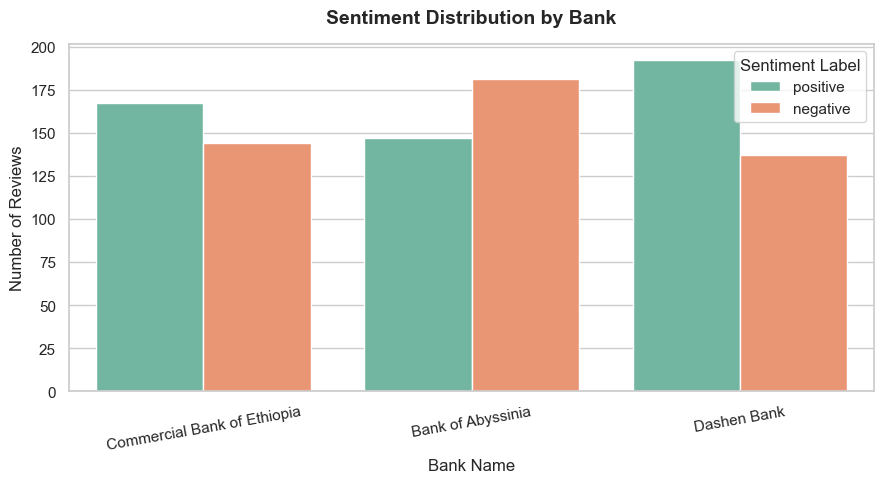

In [2]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='bank', hue='sentiment_label', palette='Set2')
plt.title('Sentiment Distribution by Bank', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Name', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Sentiment Label')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

---
# Plot 2: Rating Distribution per Bank

C:\Users\HP\AppData\Local\Temp\ipykernel_17016\3247677409.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bank', y='rating', palette='Pastel1', width=0.4)


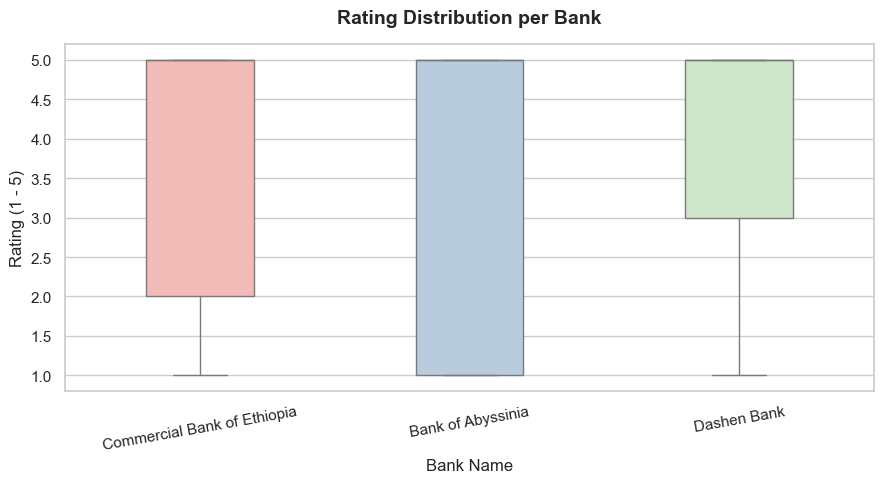

In [3]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='bank', y='rating', palette='Pastel1', width=0.4)
plt.title('Rating Distribution per Bank', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bank Name', fontsize=12)
plt.ylabel('Rating (1 - 5)', fontsize=12)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

---
# Plot 3: Top Themes Frequency per Bank

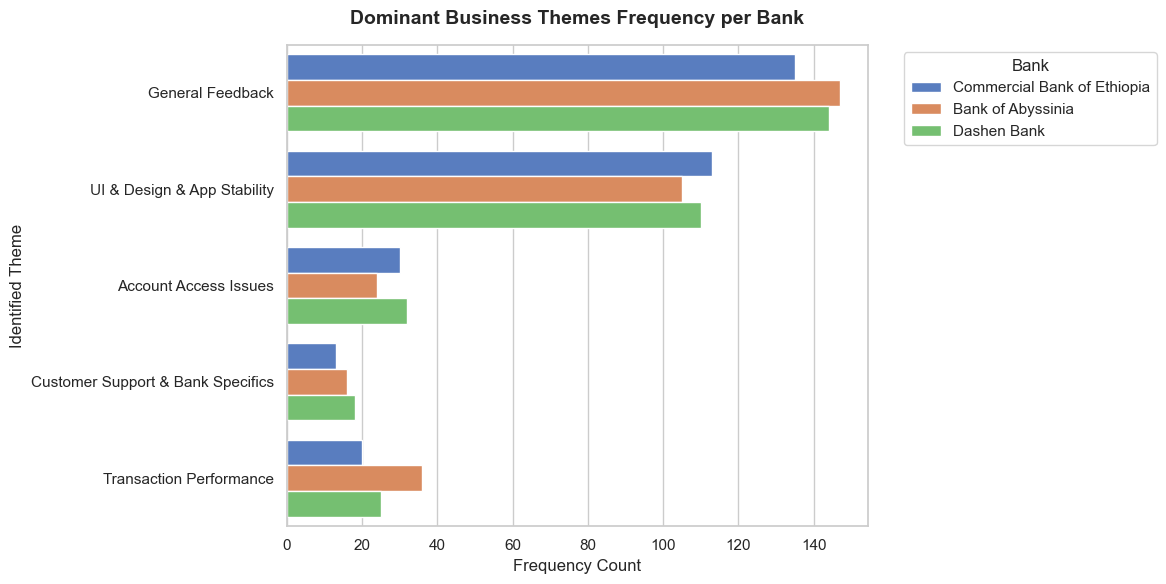

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='identified_theme', hue='bank', palette='muted')
plt.title('Dominant Business Themes Frequency per Bank', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency Count', fontsize=12)
plt.ylabel('Identified Theme', fontsize=12)
plt.legend(title='Bank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
# Plot 4: Sentiment Trend Over Time

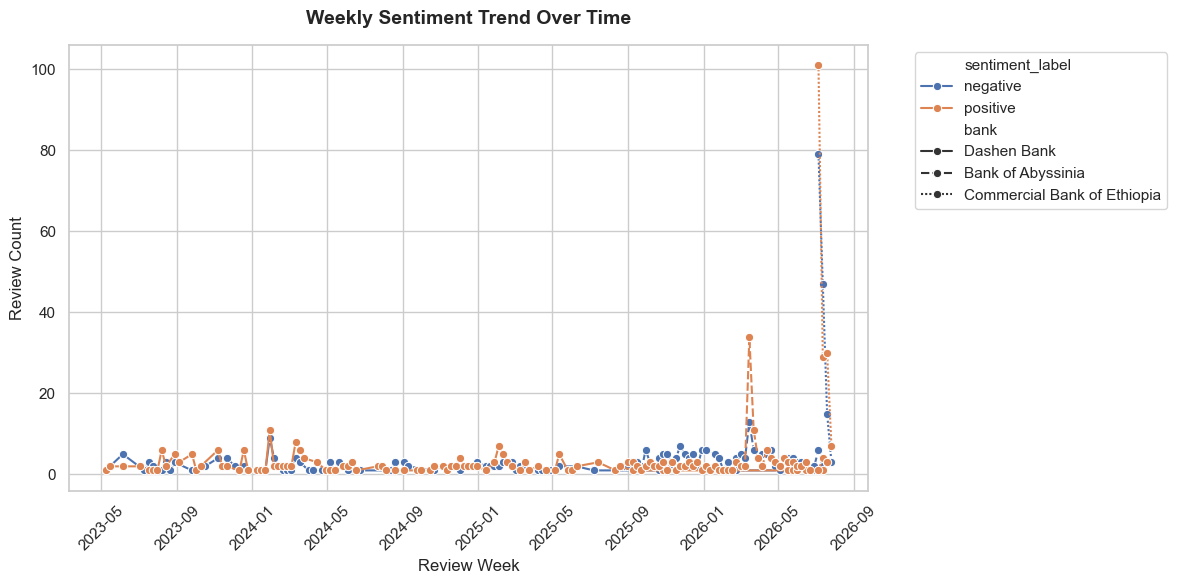

In [5]:
plt.figure(figsize=(12, 6))

df['week'] = df['review_date'].dt.to_period('W').dt.start_time
trend_df = df.groupby(['week', 'bank', 'sentiment_label']).size().reset_index(name='count')

sns.lineplot(data=trend_df, x='week', y='count', hue='sentiment_label', style='bank', marker='o')
plt.title('Weekly Sentiment Trend Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Review Week', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()